<a href="https://colab.research.google.com/github/Angel-crypt/face2emotion-AIML/blob/main/face2emotion_AIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [22]:
import os
import time
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from scipy import stats
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [23]:
path = kagglehub.dataset_download("samithsachidanandan/human-face-emotions")

Using Colab cache for faster access to the 'human-face-emotions' dataset.


In [24]:
original_path = f"{path}/Data"
desired_emotions = ["Angry", "Happy", "Sad"]

## Crear dataset con las imagenes de las emociones a clasificar

In [25]:
# Crear una lista con las rutas de las imágenes de las emociones deseadas
data = []
for emotion in desired_emotions:
    emotion_path = os.path.join(original_path, emotion)
    if os.path.exists(emotion_path):
        for imagen in os.listdir(emotion_path):
            # Guardamos la ruta completa de la imagen y su etiqueta (emoción)
            completed_path = os.path.join(emotion_path, imagen)
            data.append({"Path": completed_path, "Emotion": emotion})

# Convertimos a DataFrame de Pandas
df_raw = pd.DataFrame(data)

# Mezclar el dataset (shuffle)
df_raw = df_raw.sample(frac=1).reset_index(drop=True)

print(df_raw.head())

                                                Path Emotion
0  /kaggle/input/human-face-emotions/Data/Happy/6...   Happy
1  /kaggle/input/human-face-emotions/Data/Angry/3...   Angry
2  /kaggle/input/human-face-emotions/Data/Sad/798...     Sad
3  /kaggle/input/human-face-emotions/Data/Angry/3...   Angry
4  /kaggle/input/human-face-emotions/Data/Happy/8...   Happy


## Entender distribucion inicial

In [26]:
frecuency = df_raw['Emotion'].value_counts()
representation = (df_raw['Emotion'].value_counts(normalize=True) * 100).round(2)

resumen = pd.DataFrame({
    'Frecuencia': frecuency,
    'Representacion (%)': representation
})

print(f'Total de imágenes: {len(df_raw)}\n')
print(resumen)

Total de imágenes: 41140

         Frecuencia  Representacion (%)
Emotion                                
Happy         18439               44.82
Sad           12553               30.51
Angry         10148               24.67


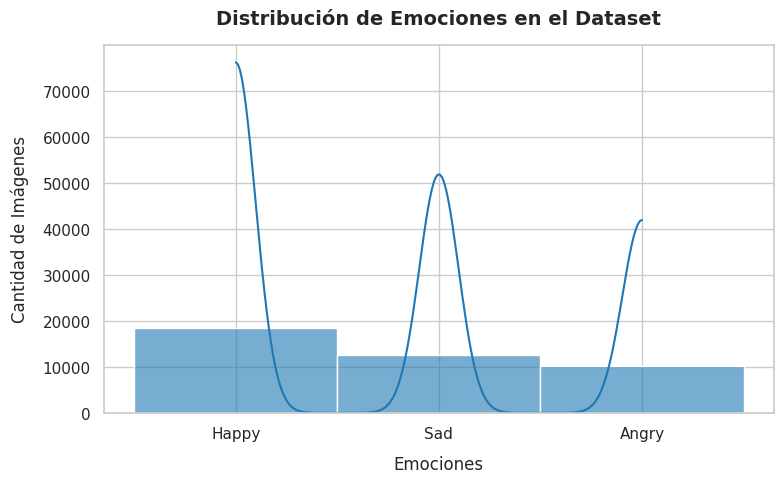

In [27]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))

df_raw['Emotion_Num'] = df_raw['Emotion'].map({'Happy': 0, 'Sad': 1, 'Angry': 2})

sns.histplot(
    data=df_raw,
    x='Emotion_Num',
    kde=True,
    discrete=True,
    color='#1f77b4',
    alpha=0.6,
    ax=ax
)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Happy', 'Sad', 'Angry'])

ax.set_title("Distribución de Emociones en el Dataset", fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel("Emociones", fontsize=12, labelpad=10)
ax.set_ylabel("Cantidad de Imágenes", fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

## Balancear clases recortando

In [28]:
# Cantidad mínima de imágenes
min_imgs = df_raw['Emotion'].value_counts().min()

# Agrupar por emocion y tomar muestra aleatoria de ese tamano minimo
df_balanced = df_raw.groupby('Emotion').sample(n=min_imgs, random_state=42).reset_index(drop=True)

In [29]:
frecuency = df_balanced['Emotion'].value_counts()
representation = (df_balanced['Emotion'].value_counts(normalize=True) * 100).round(2)

resumen = pd.DataFrame({
    'Frecuencia': frecuency,
    'Representacion (%)': representation
})

print(f'Total de imágenes: {len(df_balanced)}\n')
print(resumen)

Total de imágenes: 30444

         Frecuencia  Representacion (%)
Emotion                                
Angry         10148               33.33
Happy         10148               33.33
Sad           10148               33.33


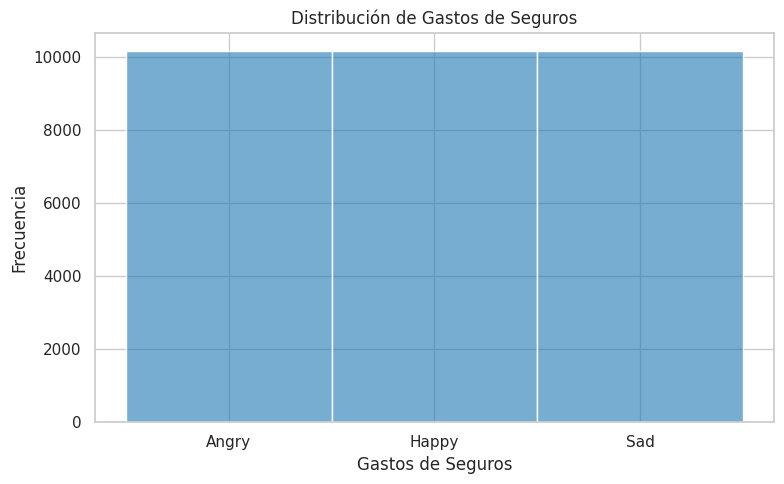

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    df_balanced['Emotion'],
    color='#1f77b4',
    alpha=0.6,
    ax=ax
  )

ax.set_title("Distribución de Emociones en el Dataset", fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel("Emociones", fontsize=12, labelpad=10)
ax.set_ylabel("Cantidad de Imágenes", fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

## Inspeccion de caracteristicas de las imagenes

In [31]:
dimensions = []
color_format = []

for path in df_balanced['Path']:
    try:
        with Image.open(path) as img:
            dimensions.append(img.size)
            color_format.append(img.mode)
    except Exception as e:
        continue

conteo_dimensiones = Counter(dimensions)
conteo_formatos = Counter(color_format)

print("Resolucion:")
for (ancho, alto), cantidad in conteo_dimensiones.items():
    porcentaje = (cantidad / len(df_balanced)) * 100
    print(f"  • {ancho} x {alto} píxeles: {cantidad} imágenes ({porcentaje:.2f}%)")

print("\nFormato de color:")
for modo, cantidad in conteo_formatos.items():
    porcentaje = (cantidad / len(df_balanced)) * 100
    if modo == 'L':
        description = "Escala de grises (1 canal / Grayscale)"
    elif modo == 'RGB':
        description = "Color verdadero (3 canales / RGB)"
    else:
        description = f"Otro modo ({modo})"

    print(f"  • {description}: {cantidad} imágenes ({porcentaje:.2f}%)")

Resolucion:
  • 48 x 48 píxeles: 29631 imágenes (97.33%)
  • 640 x 640 píxeles: 495 imágenes (1.63%)
  • 4368 x 2912 píxeles: 1 imágenes (0.00%)
  • 5472 x 3648 píxeles: 2 imágenes (0.01%)
  • 5511 x 3674 píxeles: 1 imágenes (0.00%)
  • 4000 x 6000 píxeles: 15 imágenes (0.05%)
  • 6000 x 3376 píxeles: 2 imágenes (0.01%)
  • 3456 x 5184 píxeles: 5 imágenes (0.02%)
  • 5536 x 4160 píxeles: 1 imágenes (0.00%)
  • 8192 x 5461 píxeles: 3 imágenes (0.01%)
  • 4480 x 6720 píxeles: 6 imágenes (0.02%)
  • 3500 x 2333 píxeles: 1 imágenes (0.00%)
  • 8192 x 6144 píxeles: 2 imágenes (0.01%)
  • 5184 x 3456 píxeles: 3 imágenes (0.01%)
  • 6720 x 4480 píxeles: 4 imágenes (0.01%)
  • 6000 x 5709 píxeles: 1 imágenes (0.00%)
  • 6000 x 3368 píxeles: 1 imágenes (0.00%)
  • 4016 x 6016 píxeles: 3 imágenes (0.01%)
  • 6338 x 4225 píxeles: 1 imágenes (0.00%)
  • 3555 x 2370 píxeles: 1 imágenes (0.00%)
  • 4000 x 5334 píxeles: 3 imágenes (0.01%)
  • 6000 x 4000 píxeles: 12 imágenes (0.04%)
  • 6240 x 4160 p

## Estandarizacion de formatos

In [32]:
X_data = []
y_label = []

total_img = len(df_balanced)

print(f"Iniciando el procesamiento de {total_img} imágenes...")

start_time = time.time()
omitted_img = 0

for idx, fila in df_balanced.iterrows():
    try:
        img = Image.open(fila['Path'])

        if img.mode != 'L':
            img = img.convert('L')

        if img.size != (48, 48):
            img = img.resize((48, 48), Image.Resampling.LANCZOS)

        matriz = np.array(img, dtype=np.float32)
        tensor_normalizado = matriz / 255.0
        tensor_final = np.expand_dims(tensor_normalizado, axis=-1)

        X_data.append(tensor_final)
        y_label.append(fila['Emotion'])
    except Exception as e:
        omitted_img += 1
        print(f"Advertencia: Error al cargar {fila['Path']}: {e}")
        continue

    if (idx + 1) % 2000 == 0 or (idx + 1) == total_img:
        porcentaje = ((idx + 1) / total_img) * 100
        print(f" Procesadas: {idx + 1}/{total_img} [{porcentaje:.1f}%]")

# Conversión final a NumPy
X = np.array(X_data, dtype=np.float32)
y = np.array(y_label)

final_time = time.time()

total_time = final_time - start_time
minutes = int(total_time // 60)
seconds = int(total_time % 60)

print(f"Tiempo total de ejecución: {minutes} min {seconds} seg")
print(f"Imágenes procesadas exitosamente: {X.shape}")
print(f"Imágenes omitidas por error: {omitted_img}")
print(f"Etiquetas guardadas: {y.shape}")

Iniciando el procesamiento de 30444 imágenes...
 Procesadas: 2000/30444 [6.6%]
 Procesadas: 4000/30444 [13.1%]
 Procesadas: 6000/30444 [19.7%]
 Procesadas: 8000/30444 [26.3%]
 Procesadas: 10000/30444 [32.8%]
 Procesadas: 12000/30444 [39.4%]
 Procesadas: 14000/30444 [46.0%]
 Procesadas: 16000/30444 [52.6%]
 Procesadas: 18000/30444 [59.1%]
 Procesadas: 20000/30444 [65.7%]
 Procesadas: 22000/30444 [72.3%]
 Procesadas: 24000/30444 [78.8%]
 Procesadas: 26000/30444 [85.4%]
 Procesadas: 28000/30444 [92.0%]
 Procesadas: 30000/30444 [98.5%]
 Procesadas: 30444/30444 [100.0%]
Tiempo total de ejecución: 2 min 7 seg
Imágenes procesadas exitosamente: (30444, 48, 48, 1)
Imágenes omitidas por error: 0
Etiquetas guardadas: (30444,)


In [33]:
# Estadísticas del Tensor X (Imágenes preprocesadas)
print("TENSOR DE ENTRADA / IMÁGENES (X):")
print(f"  • Estructura total (Shape): {X.shape}")
print(f"  • Cantidad total de muestras: {X.shape[0]} imágenes")
print(f"  • Dimensión de cada imagen: {X.shape[1]} x {X.shape[2]} píxeles")
print(f"  • Canales de color ajustados: {X.shape[3]} (1 = Escala de grises pura)")
print(f"  • Tipo de datos en memoria (Dtype): {X.dtype}")
print(f"  • Rango de los píxeles: Mínimo = {X.min():.2f} | Máximo = {X.max():.2f}")
print(f"  • Peso total en memoria RAM: {X.nbytes / (1024**2):.2f} MB")

# Estadísticas del Vector y (Etiquetas/Clases)
print("\nVECTOR DE SALIDA / ETIQUETAS (y):")
print(f"  • Estructura total (Shape): {y.shape}")
print(f"  • Tipo de dato (Dtype): {y.dtype}")

TENSOR DE ENTRADA / IMÁGENES (X):
  • Estructura total (Shape): (30444, 48, 48, 1)
  • Cantidad total de muestras: 30444 imágenes
  • Dimensión de cada imagen: 48 x 48 píxeles
  • Canales de color ajustados: 1 (1 = Escala de grises pura)
  • Tipo de datos en memoria (Dtype): float32
  • Rango de los píxeles: Mínimo = 0.00 | Máximo = 1.00
  • Peso total en memoria RAM: 267.57 MB

VECTOR DE SALIDA / ETIQUETAS (y):
  • Estructura total (Shape): (30444,)
  • Tipo de dato (Dtype): <U5


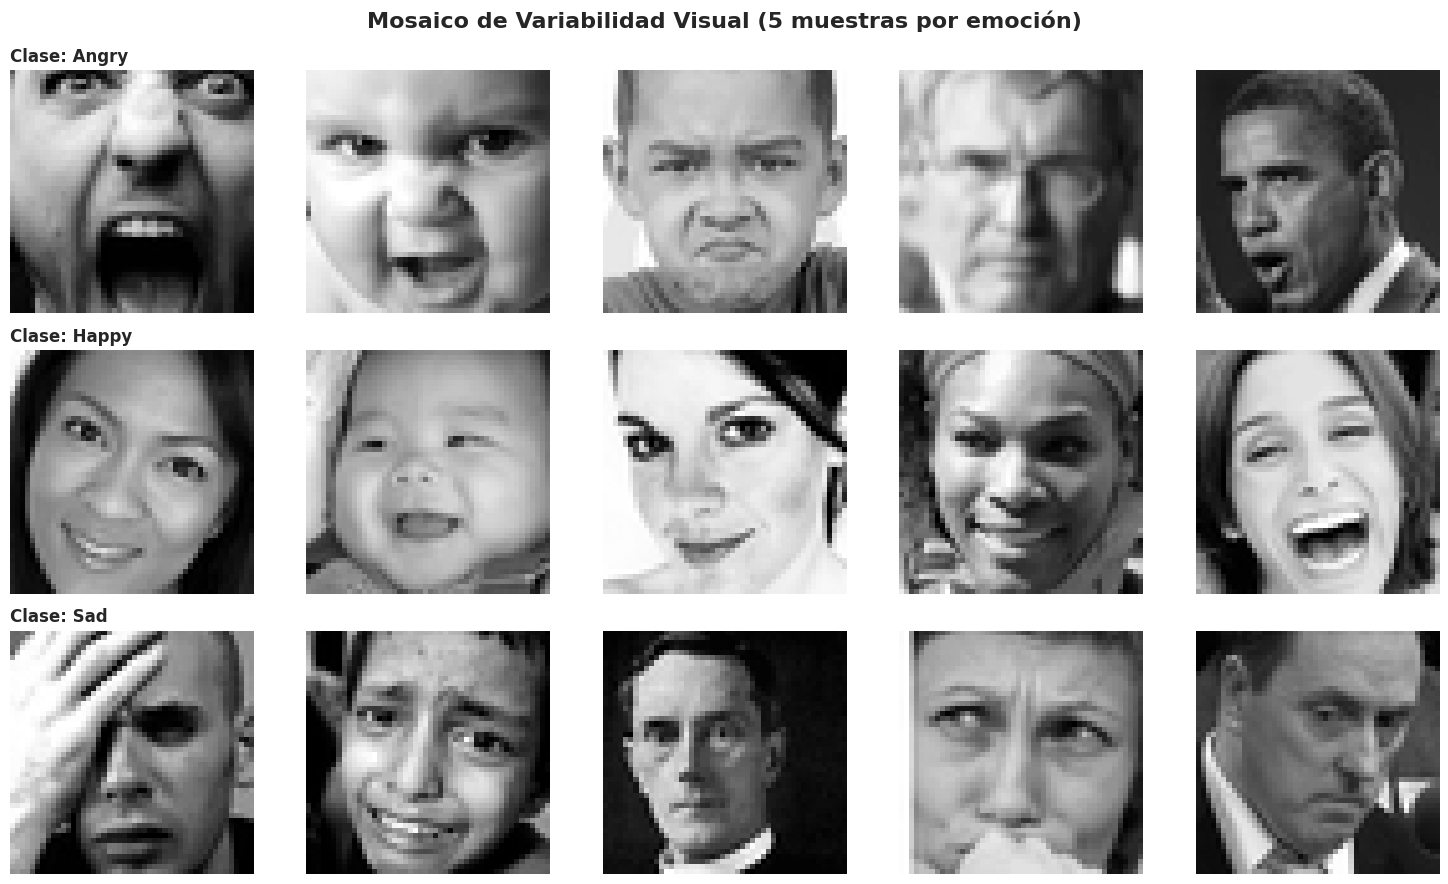

In [34]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
clases_unicas = np.unique(y)

for row, emocion in enumerate(clases_unicas):
    indices_clase = np.where(y == emocion)[0]
    indices_mostrar = np.random.choice(indices_clase, size=5, replace=False)

    for col, idx in enumerate(indices_mostrar):
        tensor_img = X[idx]
        img_mostrar = np.squeeze(tensor_img)

        ax = axes[row, col]
        ax.imshow(img_mostrar, cmap='gray')
        ax.axis('off')

        if col == 0:
            ax.set_title(f"Clase: {emocion}", fontsize=12, fontweight='bold', loc='left')

plt.suptitle("Mosaico de Variabilidad Visual (5 muestras por emoción)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# EDA Intesidad por Pixel

In [35]:
intensidades_promedio = np.mean(X, axis=(1, 2, 3))

df_eda = pd.DataFrame({
    'Intensidad Promedio': intensidades_promedio,
    'Emocion': y
})

palette = {'Happy': '#1f77b4', 'Sad': '#ff7f0e', 'Angry': '#2ca02c'}

In [36]:
def get_stats_with_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return pd.Series({
        'Cantidad': len(series),
        'Promedio': series.mean(),
        'Mediana': series.median(),
        'Desv. Estándar': series.std(),
        'Mínimo': series.min(),
        'Q1 (25%)': q1,
        'Q3 (75%)': q3,
        'Máximo': series.max(),
        'Atípicos (Outliers)': len(outliers),
        '% Atípicos': (len(outliers) / len(series)) * 100
    })

print("ANÁLISIS ESTADÍSTICO POR EMOCIÓN:\n")
stats_df = df_eda.groupby('Emocion')['Intensidad Promedio'].apply(get_stats_with_outliers).unstack().reset_index()
stats_df.rename(columns={'Emocion': 'Emoción'}, inplace=True)

print(stats_df.to_string(index=False, formatters={
    'Cantidad': '{:,.0f}'.format,
    'Promedio': '{:.4f}'.format,
    'Mediana': '{:.4f}'.format,
    'Desv. Estándar': '{:.4f}'.format,
    'Mínimo': '{:.4f}'.format,
    'Q1 (25%)': '{:.4f}'.format,
    'Q3 (75%)': '{:.4f}'.format,
    'Máximo': '{:.4f}'.format,
    'Atípicos (Outliers)': '{:,.0f}'.format,
    '% Atípicos': '{:.2f}%'.format
}))

ANÁLISIS ESTADÍSTICO NUMÉRICO DETALLADO POR EMOCIÓN:

Emoción Cantidad Promedio Mediana Desv. Estándar Mínimo Q1 (25%) Q3 (75%) Máximo Atípicos (Outliers) % Atípicos
  Angry   10,148   0.4948  0.4978         0.1302 0.0000   0.4125   0.5851 0.9603                  75      0.74%
  Happy   10,148   0.5046  0.4984         0.1258 0.0000   0.4189   0.5883 0.9607                  56      0.55%
    Sad   10,148   0.4724  0.4731         0.1328 0.0000   0.3839   0.5625 0.9582                  55      0.54%


In [37]:
grupo_happy = df_eda[df_eda['Emocion'] == 'Happy']['Intensidad Promedio']
grupo_sad = df_eda[df_eda['Emocion'] == 'Sad']['Intensidad Promedio']
grupo_angry = df_eda[df_eda['Emocion'] == 'Angry']['Intensidad Promedio']

f_val, p_val = stats.f_oneway(grupo_happy, grupo_sad, grupo_angry)
print("\nPRUEBA ESTADÍSTICA COMPARATIVA (ANOVA de una vía):")
print(f"  • Estadístico F: {f_val:.4f}")
print(f"  • Valor p: {p_val:.4e}")
if p_val > 0.05:
    print("  • Conclusión: No hay diferencias estadísticamente significativas entre las medias de brillo de las clases (p > 0.05).")
else:
    print("  • Conclusión: Existen diferencias estadísticamente significativas entre las medias de brillo de las clases (p <= 0.05).")


PRUEBA ESTADÍSTICA COMPARATIVA (ANOVA de una vía):
  • Estadístico F: 164.2485
  • Valor p: 0.0000e+00
  • Conclusión: Existen diferencias estadísticamente significativas entre las medias de brillo de las clases (p <= 0.05).


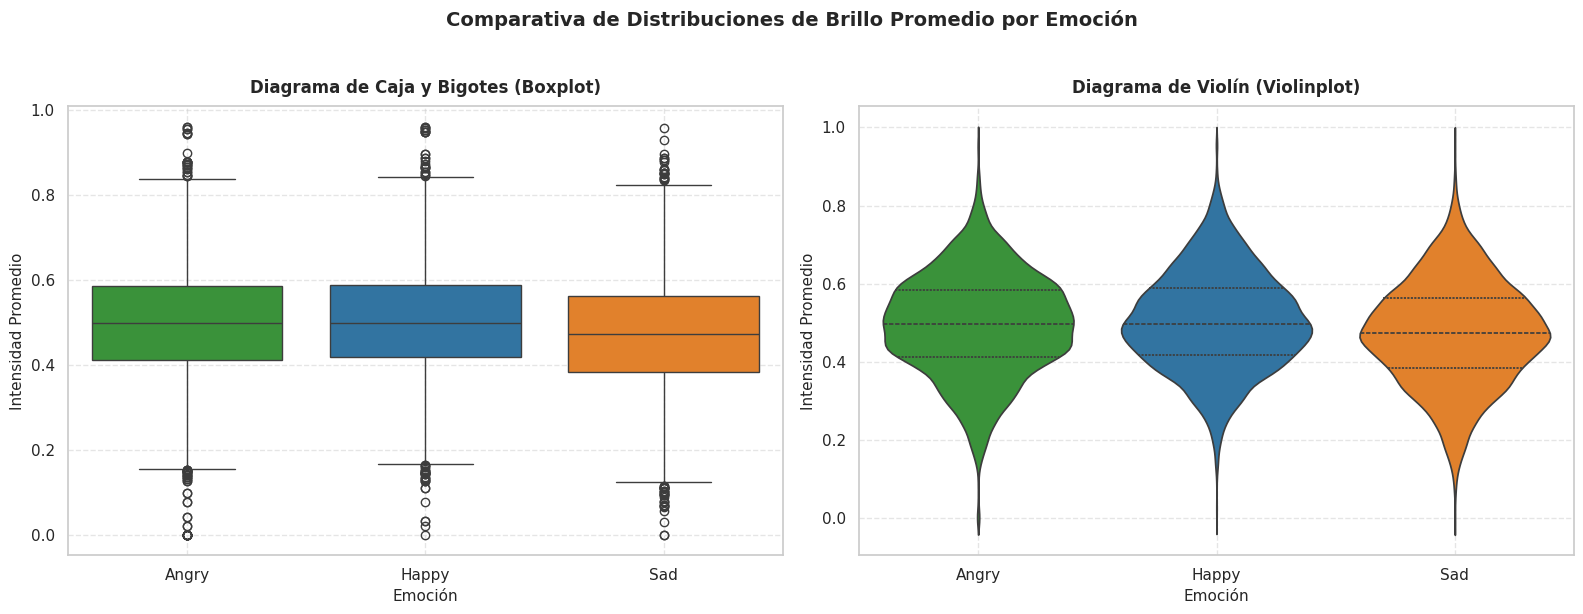

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(
    data=df_eda,
    x='Emocion',
    y='Intensidad Promedio',
    hue='Emocion',
    legend=False,
    palette=palette,
    ax=axes[0]
)
axes[0].set_title("Diagrama de Caja y Bigotes (Boxplot)", fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel("Emoción", fontsize=11)
axes[0].set_ylabel("Intensidad Promedio", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.violinplot(
    data=df_eda,
    x='Emocion',
    y='Intensidad Promedio',
    hue='Emocion',
    legend=False,
    palette=palette,
    inner="quart",
    ax=axes[1]
)
axes[1].set_title("Diagrama de Violín (Violinplot)", fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel("Emoción", fontsize=11)
axes[1].set_ylabel("Intensidad Promedio", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Comparativa de Distribuciones de Brillo Promedio por Emoción", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
df_corr = pd.get_dummies(df_eda, columns=['Emocion'], dtype=float)

corr_matrix = df_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".4f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

plt.title("Matriz de Correlación de Pearson: Intensidad vs. Emociones (One-Hot)", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

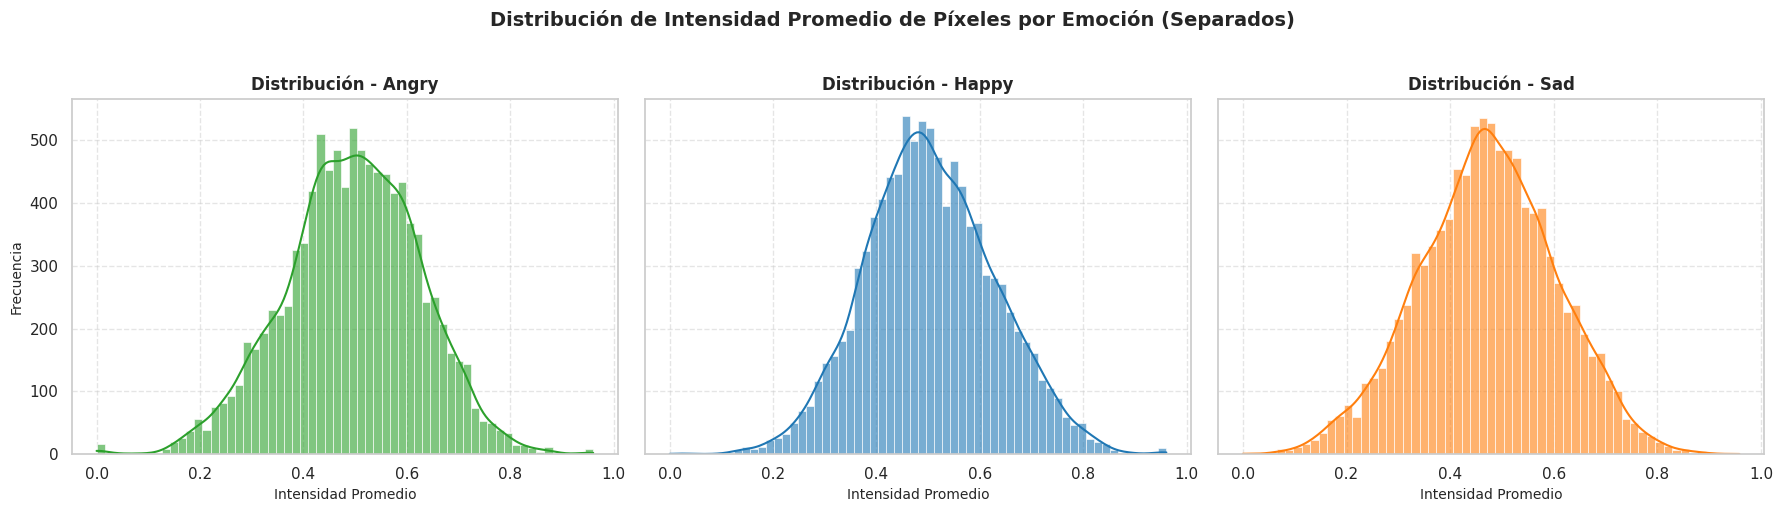

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, emocion in enumerate(['Angry', 'Happy', 'Sad']):
    sns.histplot(
        data=df_eda[df_eda['Emocion'] == emocion],
        x='Intensidad Promedio',
        kde=True,
        color=palette[emocion],
        ax=axes[i],
        alpha=0.6
    )
    axes[i].set_title(f"Distribución - {emocion}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Intensidad Promedio", fontsize=10)
    axes[i].set_ylabel("Frecuencia", fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Distribución de Intensidad Promedio de Píxeles por Emoción (Separados)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

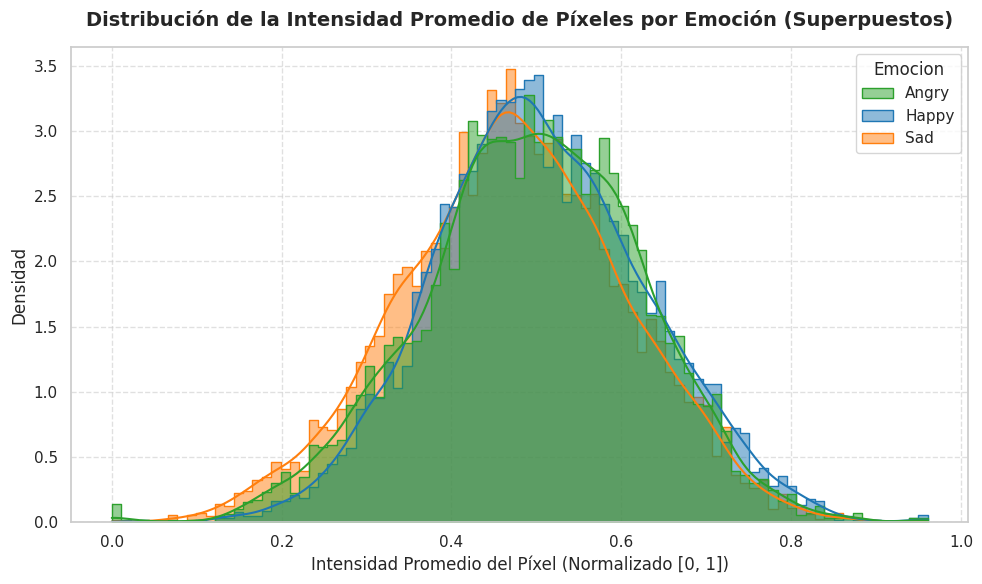

In [39]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_eda,
    x='Intensidad Promedio',
    hue='Emocion',
    kde=True,
    element='step',
    stat='density',
    common_norm=False,
    palette=palette,
    alpha=0.5
)
plt.title("Distribución de la Intensidad Promedio de Píxeles por Emoción (Superpuestos)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Intensidad Promedio del Píxel (Normalizado [0, 1])", fontsize=12)
plt.ylabel("Densidad", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Particionamiento de Datos

In [41]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

y_train_cat = to_categorical(y_train_encoded, num_classes=3)
y_val_cat = to_categorical(y_val_encoded, num_classes=3)
y_test_cat = to_categorical(y_test_encoded, num_classes=3)

print("Estructuras de los conjuntos de datos en memoria:")
print(f"  • Entrenamiento: X_train = {X_train.shape} | y_train_cat = {y_train_cat.shape}")
print(f"  • Validación:    X_val   = {X_val.shape}   | y_val_cat   = {y_val_cat.shape}")
print(f"  • Prueba:        X_test  = {X_test.shape}  | y_test_cat  = {y_test_cat.shape}")
print(f"Clases mapeadas y orden de índices: {list(label_encoder.classes_)}")

Estructuras de los conjuntos de datos en memoria:
  • Entrenamiento: X_train = (21310, 48, 48, 1) | y_train_cat = (21310, 3)
  • Validación:    X_val   = (4567, 48, 48, 1)   | y_val_cat   = (4567, 3)
  • Prueba:        X_test  = (4567, 48, 48, 1)  | y_test_cat  = (4567, 3)
Clases mapeadas y orden de índices: [np.str_('Angry'), np.str_('Happy'), np.str_('Sad')]


In [42]:
print("Distribución estratificada de clases por conjunto:")
for nombre, y_set in [("Entrenamiento", y_train), ("Validación", y_val), ("Prueba", y_test)]:
    conteo = Counter(y_set)
    total = len(y_set)
    print(f"\n{nombre} (Total: {total}):")
    for clase, cantidad in conteo.items():
        porcentaje = (cantidad / total) * 100
        print(f"  • {clase}: {cantidad} imágenes ({porcentaje:.2f}%)")

Distribución estratificada de clases por conjunto:

Entrenamiento (Total: 21310):
  • Sad: 7103 imágenes (33.33%)
  • Angry: 7104 imágenes (33.34%)
  • Happy: 7103 imágenes (33.33%)

Validación (Total: 4567):
  • Happy: 1522 imágenes (33.33%)
  • Sad: 1523 imágenes (33.35%)
  • Angry: 1522 imágenes (33.33%)

Prueba (Total: 4567):
  • Sad: 1522 imágenes (33.33%)
  • Happy: 1523 imágenes (33.35%)
  • Angry: 1522 imágenes (33.33%)


# Data Augmentation

In [43]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

eval_datagen = ImageDataGenerator()